# 1. Basic parameters

In [1]:
import networkx as nx
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes as maxes
import matplotlib.patches as mpatches

N_ITER = 100
ITERS = np.arange(N_ITER)
ALPHA = 0.3

# 2. Define the graph topology

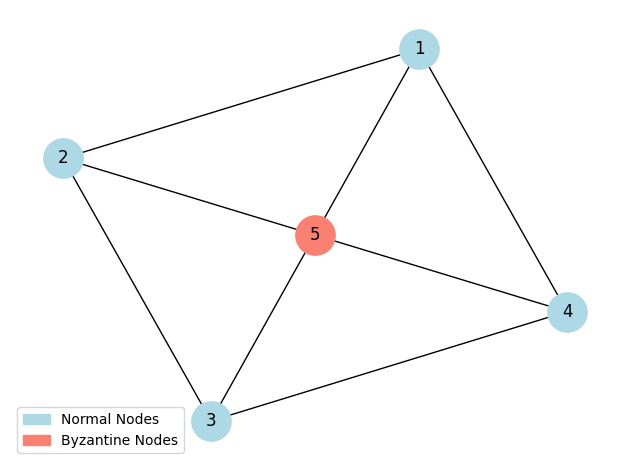

In [2]:
NORMAL_NODES = ["1", "2", "3", "4"]
NORMAL_EDGES = [
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "1"),
]
BYZANTINE_NODES = ["5"]
BYZANTINE_EDGES = [("1", "5"), ("2", "5"), ("3", "5"), ("4", "5"), ("5", "1")]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

plt.rcdefaults()

fig, ax = plt.subplots()

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

pos = nx.spring_layout(G, seed=1, k=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_edges(G, pos, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")
ax.axis("off")
plt.tight_layout()

# 3. Attacker model

In [3]:
import ray
import numpy as np
import numpy.typing as npt

from conops import Network, Graph


@ray.remote(num_cpus=1)
class Node:
    def __init__(
        self,
        node_id: str,
        neighbors: dict[str, float],
        alpha: float,
        n_iter: int,
    ) -> None:
        self.node_id = node_id

        self.network = Network(node_id, neighbors)
        self.network.start()

        self.alpha = alpha
        self.n_iter = n_iter

        self.eta = 0.005

    def __ray_shutdown__(self):
        self.network.stop()

    def _initial_honest_state(self, node_id: str) -> npt.NDArray[np.float64]:
        x = np.zeros(2)

        r0 = 1 / self.eta

        square = {
            "1": (1.0, 1.0),
            "2": (1.0, -1.0),
            "3": (-1.0, -1.0),
            "4": (-1.0, 1.0),
        }

        x[0] = r0 * square[node_id][0]
        x[1] = r0 * square[node_id][1]

        return x

    @ray.method
    def byz_node(self) -> None:
        network = self.network

        honest_nodes = ("1", "2", "3", "4")

        attack_values = {i: 2.0 * self._initial_honest_state(i) for i in honest_nodes}

        while network.round_id < self.n_iter - 1:
            n_states = network.neighborwise_exchange(attack_values)

            for i in honest_nodes:
                predicted_state = (1.0 + self.alpha) * n_states[i]
                attack_values[i] = 2.0 * predicted_state

            network.next_round()

        network._reset()

    @ray.method
    def arepc_node(
        self,
    ) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
        from arepc import ARepC

        network = self.network

        agent = ARepC(network, self.alpha, eta=self.eta, normalization="sparsemax")

        x = np.zeros((self.n_iter, 2), dtype=np.float64)

        x[0] = self._initial_honest_state(self.node_id)

        reps = {neighbor: np.zeros(self.n_iter - 1) for neighbor in network.neighbors}

        k = network.round_id

        while k < self.n_iter - 1:
            x[k + 1] = agent.weighted_mix(x[k])

            r = agent.reputations

            for j in network.neighbors:
                reps[j][k] = r[j]

            k = network.next_round()

        network._reset()

        return x, reps


ray.init()

graph = Graph(NODES, EDGES)

nodes = {i: Node.remote(i, graph[i], ALPHA, N_ITER) for i in NODES}

2026-08-27 20:27:08,560	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-27 20:27:12,181	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 
/home/rui/code/arepc/.venv/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [4]:
from conops import Graph

graph = Graph(NODES, EDGES)

arepc_refs = {i: nodes[i].arepc_node.remote() for i in NORMAL_NODES}
byz_refs = [nodes[i].byz_node.remote() for i in BYZANTINE_NODES]

arepc_data = {i: ray.get(ref) for i, ref in arepc_refs.items()}
_ = ray.get(byz_refs)

## (2) Reputation

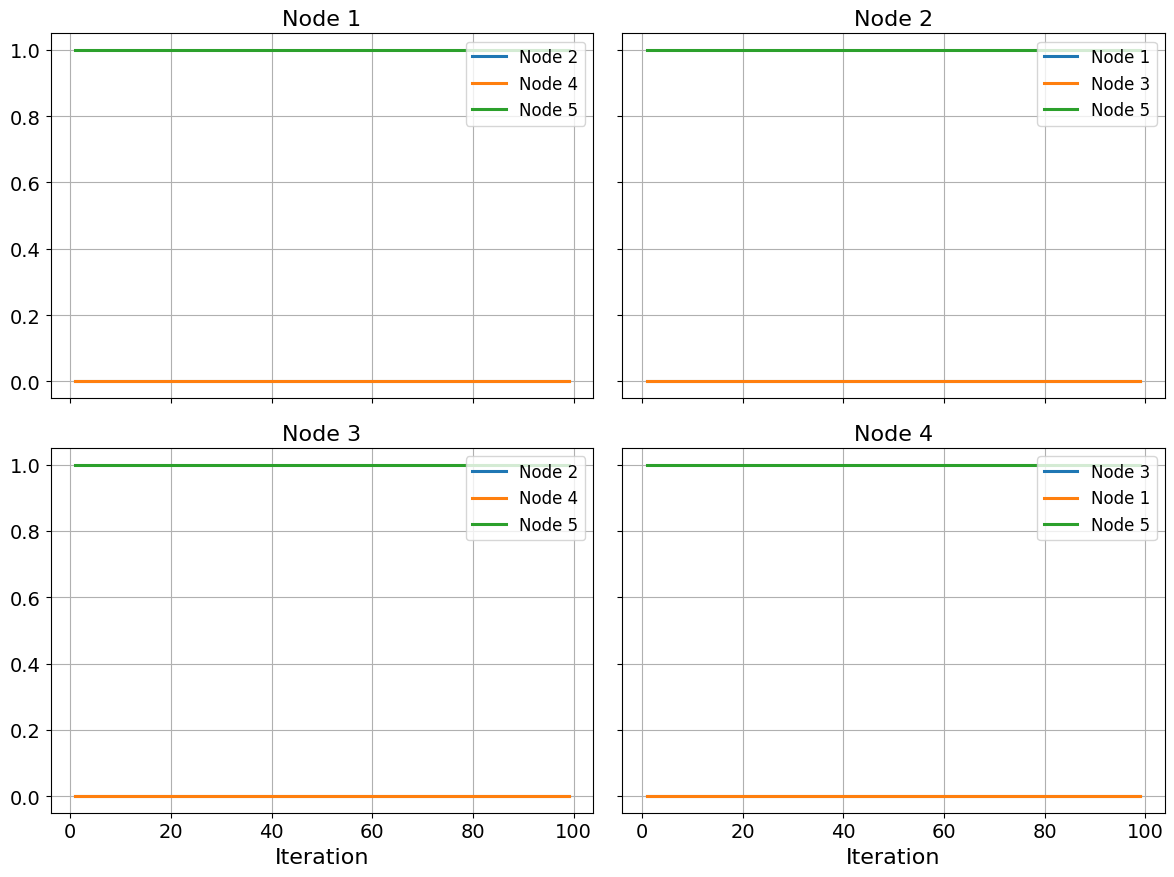

In [5]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

axes: npt.NDArray
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes_flat = axes.flatten()

arepc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat):
    ax: maxes.Axes
    reps_for_i = arepc_reps[i]
    for j in reps_for_i:
        ax.plot(ITERS[1:], reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.legend(loc="upper right")
    ax.grid()

    if i in ["3", "4"]:
        ax.set_xlabel("Iteration")

fig.tight_layout()

# 4. Comparison

Node 1 state shape: [[2.00000000e+02 2.00000000e+02]
 [2.60000000e+02 2.60000000e+02]
 [3.38000000e+02 3.38000000e+02]
 [4.39400000e+02 4.39400000e+02]
 [5.71220000e+02 5.71220000e+02]
 [7.42586000e+02 7.42586000e+02]
 [9.65361800e+02 9.65361800e+02]
 [1.25497034e+03 1.25497034e+03]
 [1.63146144e+03 1.63146144e+03]
 [2.12089987e+03 2.12089987e+03]
 [2.75716984e+03 2.75716984e+03]
 [3.58432079e+03 3.58432079e+03]
 [4.65961702e+03 4.65961702e+03]
 [6.05750213e+03 6.05750213e+03]
 [7.87475277e+03 7.87475277e+03]
 [1.02371786e+04 1.02371786e+04]
 [1.33083322e+04 1.33083322e+04]
 [1.73008318e+04 1.73008318e+04]
 [2.24910814e+04 2.24910814e+04]
 [2.92384058e+04 2.92384058e+04]
 [3.80099275e+04 3.80099275e+04]
 [4.94129058e+04 4.94129058e+04]
 [6.42367776e+04 6.42367776e+04]
 [8.35078108e+04 8.35078108e+04]
 [1.08560154e+05 1.08560154e+05]
 [1.41128200e+05 1.41128200e+05]
 [1.83466660e+05 1.83466660e+05]
 [2.38506659e+05 2.38506659e+05]
 [3.10058656e+05 3.10058656e+05]
 [4.03076253e+05 4.0307

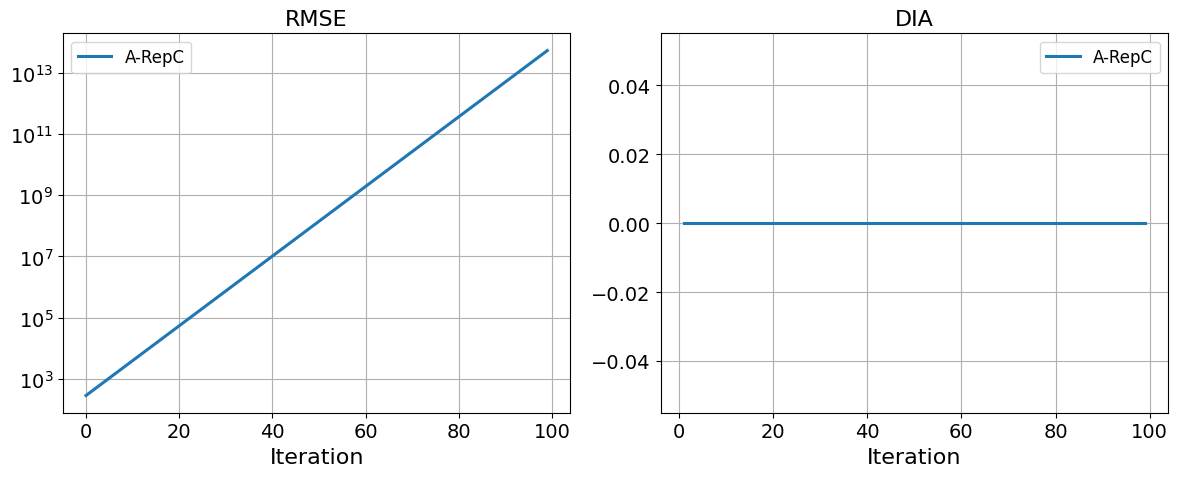

In [ ]:
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 12,
        "lines.linewidth": 2.2,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1: maxes.Axes = axes[0]
ax2: maxes.Axes = axes[1]

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
arepc_avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - arepc_avg_states
aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

ax1.semilogy(ITERS, aprec_rmse, label="A-RepC")
ax1.set_xlabel("Iteration")
ax1.set_title("RMSE")
ax1.legend()
ax1.grid()

fig.tight_layout()

arepc_x0_mean = arepc_avg_states[0]
aprec_drift = np.linalg.norm(arepc_avg_states - arepc_x0_mean[None, :], axis=1)

ax2.plot(ITERS[1:], aprec_drift[1:], label="A-RepC")
ax2.set_xlabel("Iteration")
ax2.set_title("DIA")
ax2.legend()
ax2.grid()

fig.tight_layout()

# 5. Shutdown the cluster

In [7]:
ray.shutdown()